In [1]:
import sys
sys.path.append("./src")

In [2]:
from data import DSBuilder, LMKBCDataset

In [3]:
import os
from transformers import AutoTokenizer
from utils import prepare_tokenizer, prepare_model

data_dir = "./data/lmkbc/2022"
n_ref_min = 50
n_ref_max = 50
seed = 42

n_token_gp = 4

n_token_tensor = 1

sentence_emb_mode = "ke"
sentence_emb_idx = 11

lm = "openai-community/gpt2"

tokenizer = prepare_tokenizer(AutoTokenizer.from_pretrained(lm, add_prefix_space=True))

builder = DSBuilder(
    triples_path=os.path.join(data_dir, "triples.json"),
    data_path=os.path.join(data_dir, "train.jsonl"),
    n_reference_min=n_ref_min,
    n_reference_max=n_ref_max,
    stay_ratio_min=0.0,
    stay_ratio_max=0.0,
    random_state=seed,
    n_pick=1,
    items_path=os.path.join(data_dir, "train-items.jsonl"),
    save_items=False,
    load=True
)

texts_tensor_path = os.path.join(data_dir, f"texts.{lm.replace('/', '_')}.n_token={n_token_tensor}.index={sentence_emb_idx}.tensor")
texts_tensor_path = texts_tensor_path if os.path.exists(texts_tensor_path) else os.path.join(data_dir, f"texts.{lm.replace('/', '_')}.n_token={n_token_tensor}.tensor")

entities_tensor_path = os.path.join(data_dir, f"entities.{lm.replace('/', '_')}.n_token={n_token_tensor}.index={sentence_emb_idx}.tensor")
entities_tensor_path = entities_tensor_path if os.path.exists(entities_tensor_path) else os.path.join(data_dir, f"entities.n_token={n_token_tensor}.tensor")

relations_tensor_path = os.path.join(data_dir, f"relations.{lm.replace('/', '_')}.n_token={n_token_tensor}.index={sentence_emb_idx}.tensor")
relations_tensor_path = relations_tensor_path if os.path.exists(relations_tensor_path) else os.path.join(data_dir, f"relations.n_token={n_token_tensor}.tensor")

ds = LMKBCDataset(
    builder,
    os.path.join(data_dir, "texts.txt"),
    os.path.join(data_dir, "entities.txt"),
    os.path.join(data_dir, "relations.txt"),
    os.path.join(data_dir, "entities_alias.jsonl"),
    n_tokens=n_token_gp,
    tokenizer=tokenizer,
    texts_tensor_path=texts_tensor_path,
    entities_tensor_path=entities_tensor_path,
    relations_tensor_path=relations_tensor_path,
    sentence_emb_mode=sentence_emb_mode,
    sentence_emb_index=sentence_emb_idx
)

In [4]:
prompt_idx = 0

_ = ds.prepare_generate(prompt_idx=prompt_idx)

1200it [00:00, 18287.92it/s]


In [5]:
from model import KGATModel, AutoModelForLMKBC, GraphPrefix, Pipeline

In [6]:
kgat_model = KGATModel(
    d_model=768,
    d_ff=758//2,
    heads=8,
    beta=False,
    dropout=0.0,
    bias=True,
    transform_relation=False,
    num_block=2
)

# kgat_model = KGATModel.load(path) # use this instead for loading checkpoint

language_model = AutoModelForLMKBC.from_pretrained(lm, device_map="auto", output_attentions=True)
language_model = prepare_model(language_model, tokenizer)

graph_prefix = GraphPrefix(in_channels=ds.texts_attr.shape[1], d_model=language_model.embed_dim, n_token=n_token_gp, bias=True)

# graph_prefix = GraphPrefix.load(path) # use this instead for loading checkpoint

pipe = Pipeline(kgat_model=kgat_model, graph_prefix=graph_prefix, language_model=language_model)

In [7]:
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
pipe.kgat_model.to(device)
pipe.graph_prefix.to(device)

GraphPrefix(
  (lin): Linear(768, 3072, bias=True)
)

# 1. Explain By Language Model

In [8]:
data_index = 0

In [9]:
ds[data_index][-2]

0.3333333333333333

In [10]:
ds.get(data_index)["input_ids"]

tensor([[ 5765, 46932,    11,  1912,   319,   262,  4941,  4600, 50257, 50257,
         50257, 50257,  4600,    11,  1844,   262,  1708, 15055,   351,   262,
          5794,   357,  2426,  1058,   311,   930,  8695,  1058,   371,   930,
          2134,  1058,   440,   930,  4938,  1058,  2081,  1220,  3991,  1267,
         50256,   837,  6070,  2134,   351,   399, 11651,   611,  2147, 15959,
          1058,   357,  2426,  1058,  4013,   316, 44895,   930,  8695,  1058,
         24872,  7293,   633, 20180,   930,  2134,  1058]])

In [11]:
tokenizer.batch_decode(ds.get(data_index)["input_ids"], skip_special_tokens=True)

[' Use english, based on the reference ` `, complete the following triple with the format ( subject : S | relation : R | object : O | valid : true / false ), fill object with NONE if nothing satisfy : ( subject : Acetaldehyde | relation : ChemicalCompoundElement | object :']

In [13]:
from utils import KG_MASK

explain_prompt = f"`{KG_MASK*n_token_gp}` explain about " # ....

In [14]:
explain_inputs = tokenizer(explain_prompt, return_tensors="pt")

In [16]:
batch = ds.get(data_index)
batch.update(explain_inputs)
batch["n_token"] = n_token_gp

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

In [17]:
out = pipe.generate_lmkbc(**batch)

`GPT2SdpaAttention` is used but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


In [18]:
tokenizer.batch_decode(out)

['\xa0\n\n\nThe "\n\n\n\nThe']

# 2. Explain By Attention

In [20]:
batch = ds.get(data_index)
batch["n_token"] = n_token_gp

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

In [21]:
out = pipe.forward_lmkbc(**batch)

In [22]:
attention = out[-1]  # Retrieve attention from model outputs
tokens = tokenizer.convert_ids_to_tokens(batch["input_ids"][0])  # Convert input ids to token strings

This tool is designed for shorter inputs and may run slowly if the input text is very long and/or the model is very large. To mitigate this, you may wish to filter the layers displayed by setting the include_layers parameter, as described above.

In [23]:
from bertviz import model_view

model_view(attention, tokens, include_layers=[0], display_mode="light")

<IPython.core.display.Javascript object>

# 3. Explain By Retrieval Result

In [25]:
batch = ds.get(data_index)
batch.pop("input_ids")
batch.pop("attention_mask")

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

In [26]:
with torch.no_grad():
    out = kgat_model(**batch)

In [128]:
import networkx as nx
import matplotlib.pyplot as plt
from pprint import pprint

def visualize_graph(data_index, weights, spring=False, eps=1e-5):
    triples = []
    relation_map = []
    entity_map = []

    for t in ds.triples[ds[data_index][2]]:

        s = ds.entities[ds.entities_alias.loc[t[0], "alias_idx"][0]]
        r = ds.relations[t[1]]
        o = ds.entities[ds.entities_alias.loc[t[2], "alias_idx"][0]]

        if r not in relation_map:
            relation_map.append(r)
        if s not in entity_map:
            entity_map.append(s)
        if o not in entity_map:
            entity_map.append(o)
        triples.append((
            f"E{entity_map.index(s)}",
            f"R{relation_map.index(r)}",
            f"E{entity_map.index(o)}"
        ))
        # triples.append((
        #     s,
        #     r,
        #     o
        # ))
    
    # Create a graph and add edges with labels
    G = nx.Graph()
    for (s, r, o), w in zip(triples, weights):
        G.add_edge(s, o, label=r, weight=w.item())
    
    # Choose a layout for the graph
    pos = nx.circular_layout(G) if not spring else nx.spring_layout(G)

    # Draw the graph
    plt.figure(figsize=(16, 12))
    # nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='black', node_size=200, font_size=5)
    nx.draw_networkx_nodes(G, pos, node_size=150)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color='black')

    # Draw edge labels
    edge_labels = nx.get_edge_attributes(G, 'label')
    edges = G.edges(data=True)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=[d['weight'] * 2 + eps for (u, v, d) in edges], edge_color='black')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # Show the plot
    plt.show()

    entity_map = {f"E{i}" : el for i, el in enumerate(entity_map)}
    relation_map = {f"R{i}" : el for i, el in enumerate(relation_map)}
    print("ENTITY")
    pprint(entity_map)
    print("RELATION")
    pprint(relation_map)

In [129]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import json

def visualize_retrieval(data_index, kgat_model, perplexity=30):
    batch = ds.get(data_index)
    batch.pop("input_ids")
    batch.pop("attention_mask")

    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.to(device)
    
    labels = ["Q"]

    triples = {}

    for i, t in enumerate(ds.triples[ds[data_index][2]]):
        labels.append(str(i))
        triples[i] = str((
            ds.entities[ds.entities_alias.loc[t[0], "alias_idx"][0]],
            ds.relations[t[1]],
            ds.entities[ds.entities_alias.loc[t[2], "alias_idx"][0]]
        ))
    
    with torch.no_grad():
        z, relations = kgat_model.encode(batch['x'], batch['edge_index'], batch['relations'], return_attention_weights=False)

        reference_triples = kgat_model.teta_t(z, batch['edge_index'], relations)
        query = kgat_model.teta_q(batch['query'])
    
    tensor_np = torch.cat([query, reference_triples]).cpu().numpy()
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    tensor_2d = tsne.fit_transform(tensor_np)

    plt.figure(figsize=(10, 8))

    for i, label in enumerate(labels):
        plt.text(tensor_2d[i,0], tensor_2d[i,1], label, fontsize=8, ha='center', va='center', color='white')

    plt.scatter(tensor_2d[1:,0],tensor_2d[1:,1], s=150, color='blue')
    plt.scatter(tensor_2d[:1,0],tensor_2d[:1,1], s=150, color='red')
    plt.show()

    print(json.dumps(triples, indent=1))

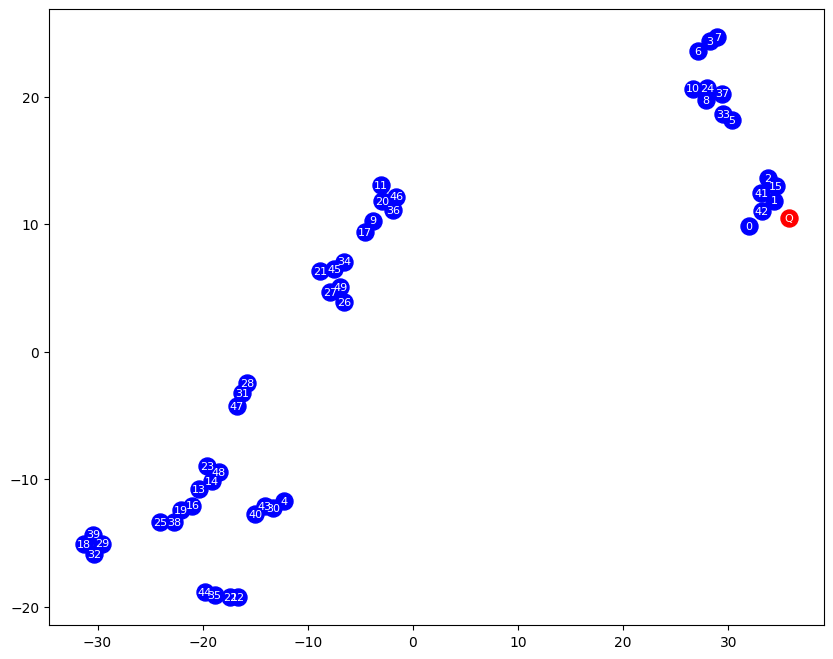

{
 "0": "('Nevada', 'StateSharesBorderState', 'Idaho')",
 "1": "('Oregon', 'StateSharesBorderState', 'Nevada')",
 "2": "('Oregon', 'StateSharesBorderState', 'washington')",
 "3": "('Tupac Shakur', 'PersonPlaceOfDeath', 'Nevada')",
 "4": "('Selenium Trioxide', 'ChemicalCompoundElement', 'selenium')",
 "5": "('Virginia', 'StateSharesBorderState', 'washington')",
 "6": "('Tupac Shakur', 'PersonPlaceOfDeath', 'university medical center of southern nevada')",
 "7": "('Tupac Shakur', 'PersonCauseOfDeath', 'homicide')",
 "8": "('Washington', 'StateSharesBorderState', 'Idaho')",
 "9": "('Thymine', 'ChemicalCompoundElement', 'oxygen')",
 "10": "('Emirate of Dubai', 'StateSharesBorderState', 'ras al khaimah')",
 "11": "('Glucagon', 'ChemicalCompoundElement', 'sulfur')",
 "12": "('Mercurous Bromide', 'ChemicalCompoundElement', 'mercury')",
 "13": "('Gluconolactone', 'ChemicalCompoundElement', 'hydrogen')",
 "14": "('Oxytocin', 'ChemicalCompoundElement', 'hydrogen')",
 "15": "('Oregon', 'StateShar

In [130]:
visualize_retrieval(data_index, kgat_model, perplexity=5)

In [131]:
weights = out.view(-1).softmax(-1)

In [132]:
weights

tensor([0.0000e+00, 1.2635e-08, 1.5369e-09, 0.0000e+00, 0.0000e+00, 1.8858e-16,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 6.0882e-38, 0.0000e+00, 7.3588e-40,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 5.4691e-07, 0.0000e+00, 7.0864e-42,
        0.0000e+00, 0.0000e+00, 1.2856e-32, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.4013e-45, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 5.0500e-37, 0.0000e+00, 0.0000e+00,
        2.3178e-29, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        1.1531e-06, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0344e-29, 0.0000e+00,
        0.0000e+00, 0.0000e+00], device='cuda:0')

In [133]:
weights.argmax()

tensor(41, device='cuda:0')

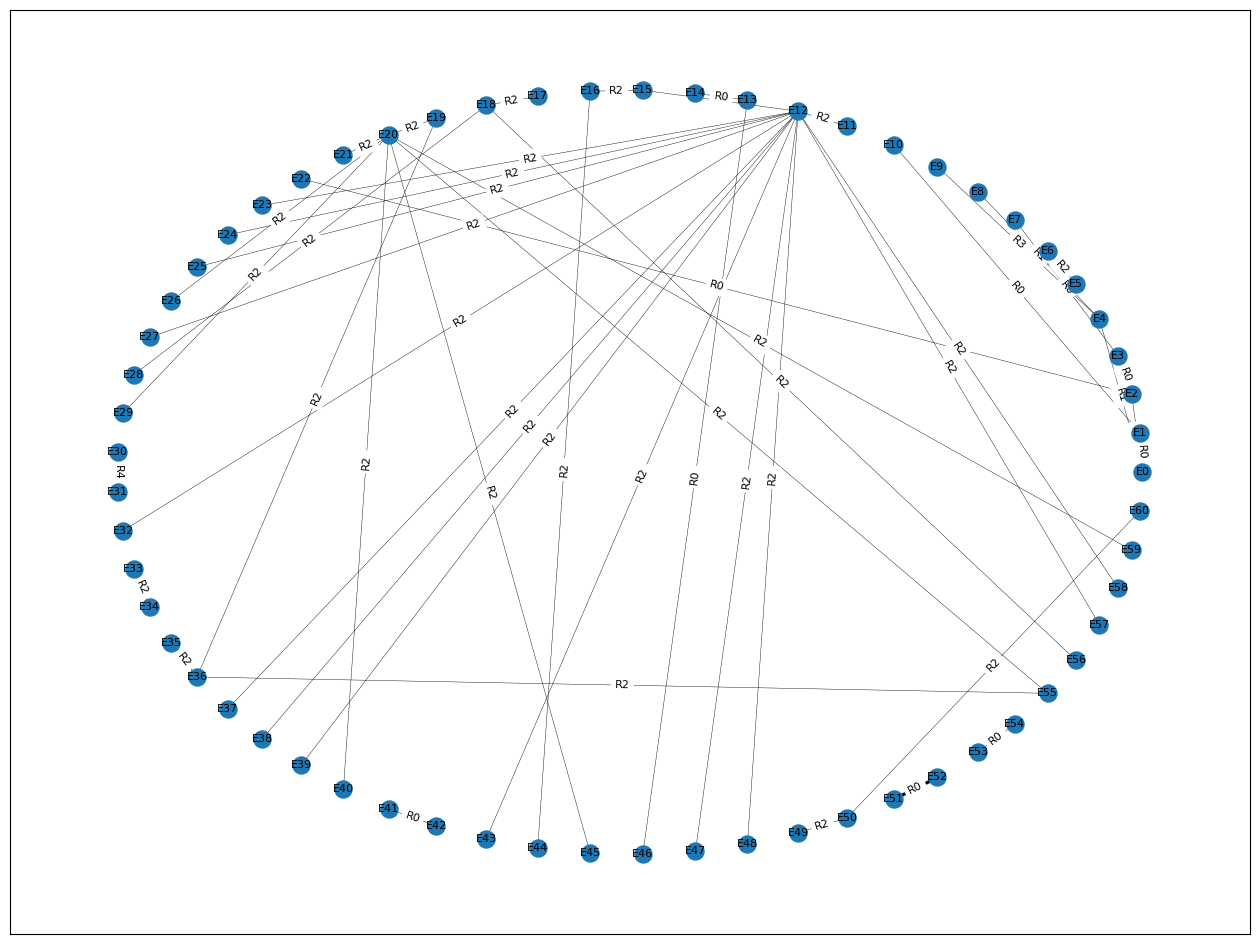

ENTITY
{'E0': 'Nevada',
 'E1': 'Idaho',
 'E10': 'Washington',
 'E11': 'Thymine',
 'E12': 'oxygen',
 'E13': 'Emirate of Dubai',
 'E14': 'ras al khaimah',
 'E15': 'Glucagon',
 'E16': 'sulfur',
 'E17': 'Mercurous Bromide',
 'E18': 'mercury',
 'E19': 'Gluconolactone',
 'E2': 'Oregon',
 'E20': 'hydrogen',
 'E21': 'Oxytocin',
 'E22': 'California',
 'E23': 'Sodium Hydroxide',
 'E24': 'Guanine',
 'E25': 'Sodium Tripolyphosphate',
 'E26': 'Zanamivir',
 'E27': 'Heroin',
 'E28': 'Mercurous Fluoride',
 'E29': 'Vinylidene Fluoride',
 'E3': 'washington',
 'E30': 'Dave Mustaine',
 'E31': 'guitar',
 'E32': 'Flavin Adenine Dinucleotide',
 'E33': 'Lead Azide',
 'E34': 'lead',
 'E35': 'Azathioprine',
 'E36': 'carbon',
 'E37': 'Valsartan',
 'E38': 'Bismuth Subsalicylate',
 'E39': 'Trimethyl Phosphite',
 'E4': 'Tupac Shakur',
 'E40': 'Adenosine Diphosphate Ribose',
 'E41': 'Hamburg',
 'E42': 'lower saxony',
 'E43': 'Harmaline',
 'E44': 'Sulfuric Acid',
 'E45': 'Triethylamine',
 'E46': 'abu dhabi',
 'E47': 

In [134]:
visualize_graph(data_index, weights, eps=0.3)

# 4. Explain By Attention Encoder

In [135]:
with torch.no_grad():
    out = kgat_model.encode(batch["x"], batch["edge_index"], batch["relations"], return_attention_weights=True)

In [136]:
layer_idx = 0
head_idx = 5

weights = out[-1][1][layer_idx][:,head_idx]

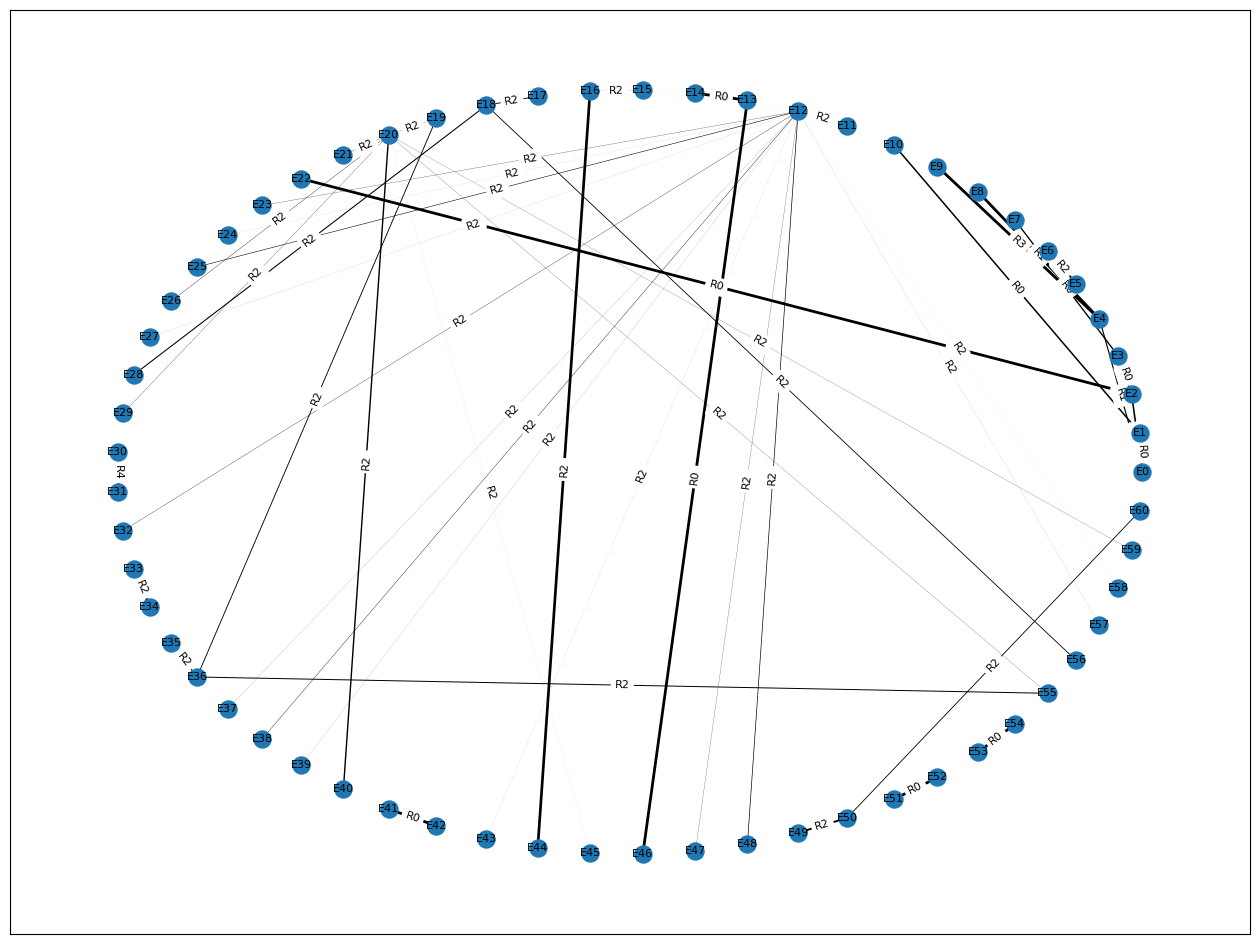

ENTITY
{'E0': 'Nevada',
 'E1': 'Idaho',
 'E10': 'Washington',
 'E11': 'Thymine',
 'E12': 'oxygen',
 'E13': 'Emirate of Dubai',
 'E14': 'ras al khaimah',
 'E15': 'Glucagon',
 'E16': 'sulfur',
 'E17': 'Mercurous Bromide',
 'E18': 'mercury',
 'E19': 'Gluconolactone',
 'E2': 'Oregon',
 'E20': 'hydrogen',
 'E21': 'Oxytocin',
 'E22': 'California',
 'E23': 'Sodium Hydroxide',
 'E24': 'Guanine',
 'E25': 'Sodium Tripolyphosphate',
 'E26': 'Zanamivir',
 'E27': 'Heroin',
 'E28': 'Mercurous Fluoride',
 'E29': 'Vinylidene Fluoride',
 'E3': 'washington',
 'E30': 'Dave Mustaine',
 'E31': 'guitar',
 'E32': 'Flavin Adenine Dinucleotide',
 'E33': 'Lead Azide',
 'E34': 'lead',
 'E35': 'Azathioprine',
 'E36': 'carbon',
 'E37': 'Valsartan',
 'E38': 'Bismuth Subsalicylate',
 'E39': 'Trimethyl Phosphite',
 'E4': 'Tupac Shakur',
 'E40': 'Adenosine Diphosphate Ribose',
 'E41': 'Hamburg',
 'E42': 'lower saxony',
 'E43': 'Harmaline',
 'E44': 'Sulfuric Acid',
 'E45': 'Triethylamine',
 'E46': 'abu dhabi',
 'E47': 

In [137]:
visualize_graph(data_index, weights)

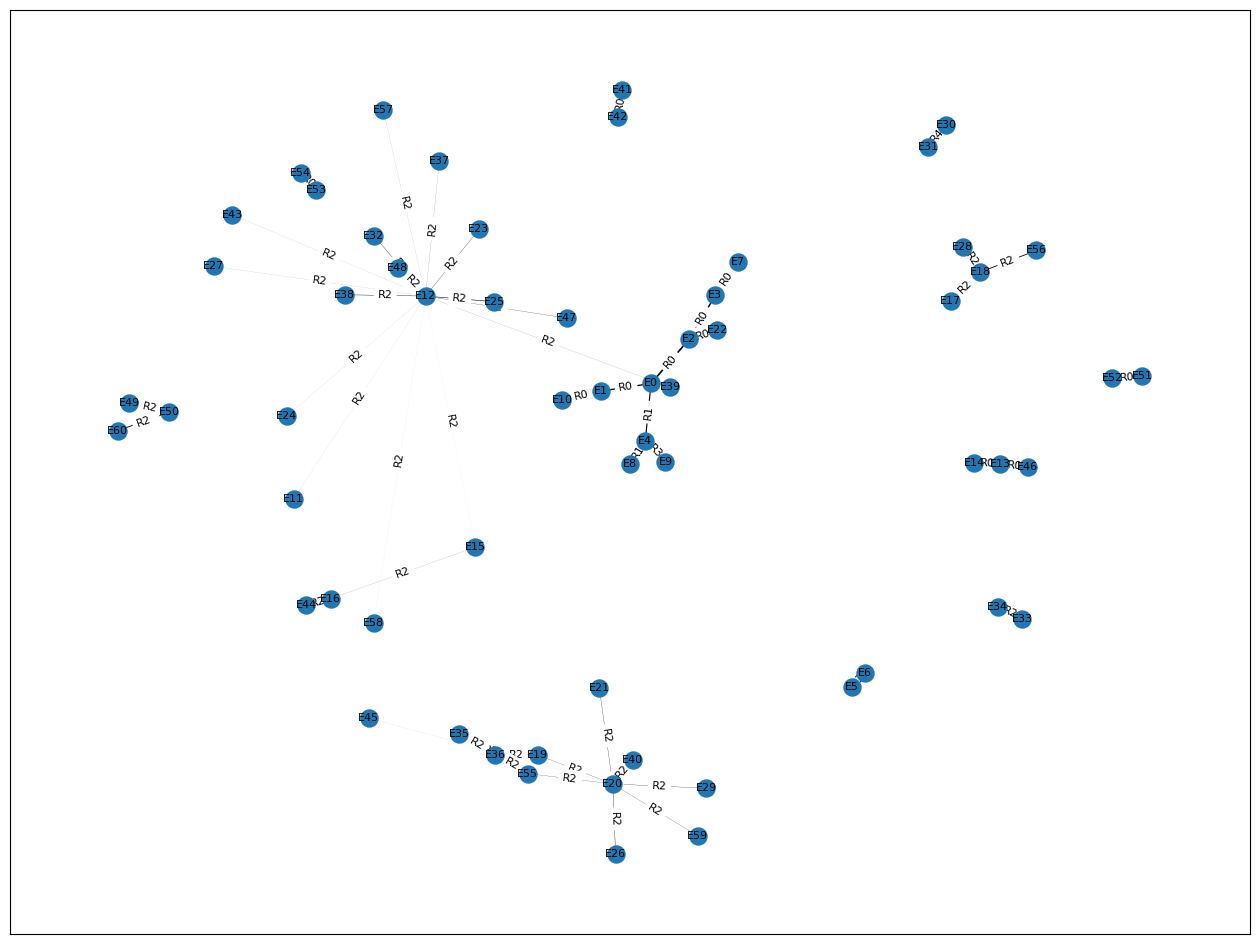

ENTITY
{'E0': 'Nevada',
 'E1': 'Idaho',
 'E10': 'Washington',
 'E11': 'Thymine',
 'E12': 'oxygen',
 'E13': 'Emirate of Dubai',
 'E14': 'ras al khaimah',
 'E15': 'Glucagon',
 'E16': 'sulfur',
 'E17': 'Mercurous Bromide',
 'E18': 'mercury',
 'E19': 'Gluconolactone',
 'E2': 'Oregon',
 'E20': 'hydrogen',
 'E21': 'Oxytocin',
 'E22': 'California',
 'E23': 'Sodium Hydroxide',
 'E24': 'Guanine',
 'E25': 'Sodium Tripolyphosphate',
 'E26': 'Zanamivir',
 'E27': 'Heroin',
 'E28': 'Mercurous Fluoride',
 'E29': 'Vinylidene Fluoride',
 'E3': 'washington',
 'E30': 'Dave Mustaine',
 'E31': 'guitar',
 'E32': 'Flavin Adenine Dinucleotide',
 'E33': 'Lead Azide',
 'E34': 'lead',
 'E35': 'Azathioprine',
 'E36': 'carbon',
 'E37': 'Valsartan',
 'E38': 'Bismuth Subsalicylate',
 'E39': 'Trimethyl Phosphite',
 'E4': 'Tupac Shakur',
 'E40': 'Adenosine Diphosphate Ribose',
 'E41': 'Hamburg',
 'E42': 'lower saxony',
 'E43': 'Harmaline',
 'E44': 'Sulfuric Acid',
 'E45': 'Triethylamine',
 'E46': 'abu dhabi',
 'E47': 

In [138]:
visualize_graph(data_index, weights, spring=True)